In [1]:
%load_ext autoreload
%autoreload 2

import argparse
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import mplhep
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.model_selection import train_test_split
from torch_geometric.loader import DataLoader
from tqdm import tqdm

from analysis.gravnet.model import NeutrinoGravNetNodesGraphFaser
from analysis.utils.colors import TangoColors
from analysis.utils.datasets import CNNProjectionDataset
from analysis.utils.geometry import Geometry, get_rebinned_geometry
from analysis.utils.models import GraphClassifier, MuonHitNetClassifier
from analysis.utils.plot_utils import setup
from analysis.utils.torch_geometric_utils import (
    evaluate_gravnet_model,
    evaluate_pointnetpp_model,
)
from analysis.utils.torch_utils import (
    get_device,
    load_weights,
    show_model,
    train,
)
from analysis.utils.truth import TruthParticle, get_truth_particle
from analysis.utils.units import um
from analysis.utils.utils import (
    get_figures_path,
    get_npy_path,
    get_parquet_path,
    get_torch_path,
    get_weights_path,
)
from analysis.utils.validation_utils import (
    get_accuracy_dict,
    plot_confusion_matrix,
    plot_precision_recall_curve,
    plot_probabilities,
    plot_roc_curve,
    plot_training_metrics,
)

/Users/tboeckh/Library/Caches/pypoetry/virtualenvs/analysis-mEzhAUyO-py3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
setup()

In [3]:
@dataclass
class HitType:
    idx: int
    label: str
    latex_name: str
    color: str = "black"


other_hit = HitType(0, "other", "Other", TangoColors.sky_blue)
e_hit = HitType(1, "e", r"$e^{\pm}$", TangoColors.scarlet_red)
mu_hit = HitType(2, "mu", r"$\mu^{\pm}$", TangoColors.chameleon)
# hits = [other_hit, other_e_hit, primary_e_hit, primary_mu_hit]
hits = [other_hit, e_hit, mu_hit]

In [4]:
@dataclass
class NuType:
    idx: int
    label: str
    latex_name: str


nun = NuType(0, "nun", "NC")
nue = NuType(1, "nue", r"CC $\nu_{e}$")
num = NuType(2, "num", r"CC $\nu_{\mu}$")
nus = [nun, nue, num]

# Main


In [5]:
def get_str_from_run(run: int) -> str:
    """Convert run number to string label."""
    if run % 4 == 0:
        return "nue"
    elif run % 4 == 1:
        return "num"
    elif run % 4 == 2:
        return "nut"
    elif run % 4 == 3:
        return "nun"

In [15]:
model = "gravnet_nodes_graph_faser_all_events_det_5mm_0_scint_layer"
weights_dir_path = get_weights_path() / model
weights_path = weights_dir_path / "best_model.pt"
# weights_path = get_weights_path() / f"{model}/checkpoint_epoch_60.pt"
figures_path = get_figures_path() / model
figures_path.mkdir(parents=True, exist_ok=True)

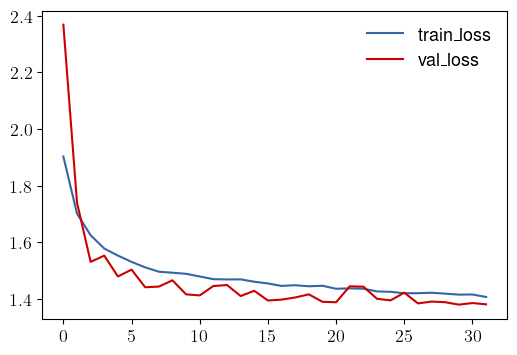

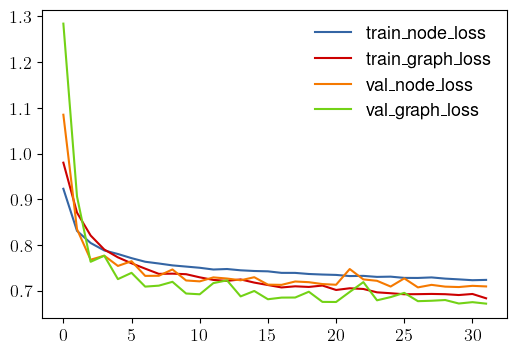

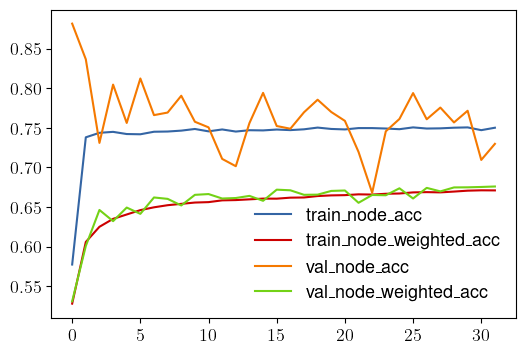

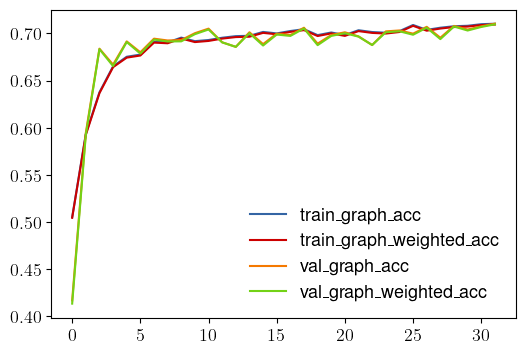

In [17]:
train_metrics = np.load(weights_dir_path / "training_metrics.npz")

epochs = np.arange(32)
fig, ax = plt.subplots(figsize=(6, 4))
for key in ["train_loss", "val_loss"]:
    ax.plot(epochs, train_metrics[key], label=key)
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
for key in ["train_node_loss", "train_graph_loss", "val_node_loss", "val_graph_loss"]:
    ax.plot(epochs, train_metrics[key], label=key)
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
for key in [
    "train_node_acc",
    "train_node_weighted_acc",
    "val_node_acc",
    "val_node_weighted_acc",
]:
    ax.plot(epochs, train_metrics[key], label=key)
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
for key in [
    "train_graph_acc",
    "train_graph_weighted_acc",
    "val_graph_acc",
    "val_graph_weighted_acc",
]:
    ax.plot(epochs, train_metrics[key], label=key)
ax.legend()
plt.show()

In [18]:
def loda_data(
    run: int, chunks: list[int], data_dir: str, num_events: int | None = None
) -> list[torch.Tensor]:
    torch_path = get_torch_path()
    dataset = []
    for chunk in chunks:
        run_str = get_str_from_run(run)
        chunk_path = torch_path / f"{run}/{data_dir}/{run_str}_{chunk:03d}.pt"
        chunk_data = torch.load(chunk_path, weights_only=False)
        if num_events is not None:
            chunk_data = chunk_data[:num_events]
        dataset.extend(chunk_data)
    return dataset

In [22]:
chunks = [5, 6]
num_events = 500
data_dir = "pointnetpp_faser_all_events"
nue_data = loda_data(run=10024, chunks=chunks, data_dir=data_dir, num_events=num_events)
num_data = loda_data(run=10025, chunks=chunks, data_dir=data_dir, num_events=num_events)
nun_data = loda_data(run=10027, chunks=chunks, data_dir=data_dir, num_events=num_events)
dataset = nue_data + num_data + nun_data
data_loader = DataLoader(dataset)
print(len(nue_data), len(num_data), len(nun_data), len(dataset))

1000 1000 1000 3000


In [23]:
device = get_device("cpu")

model = NeutrinoGravNetNodesGraphFaser(
    input_dim=dataset[0].x.shape[1],
    faser_dim=dataset[0].x_faser.shape[0],
    # num_graph_classes=2,
    num_graph_classes=len(nus),
    num_node_classes=len(hits),
)
model = model.to(device)

load_weights(model, device=device, weights_path=weights_path)

Using device: cpu


In [24]:
y_node_true, y_node_pred, y_node_prob, y_graph_true, y_graph_pred, y_graph_prob = (
    evaluate_pointnetpp_model(
        model=model,
        test_loader=data_loader,
        device=device,
        use_faser=True,
    )
)

Evaluating: 100%|██████████| 3000/3000 [06:41<00:00,  7.48it/s]


In [25]:
y_node_true_flat = np.concatenate(y_node_true)
y_node_pred_flat = np.concatenate(y_node_pred)
y_node_prob_flat = np.concatenate(y_node_prob)

y_graph_true_flat = np.concatenate(y_graph_true)
y_graph_pred_flat = np.concatenate(y_graph_pred)
y_graph_prob_flat = np.concatenate(y_graph_prob)

In [26]:
acc_dict = get_accuracy_dict(
    y_true=y_node_true_flat,
    y_pred=y_node_pred_flat,
    class_names=[hit.label for hit in hits],
)
for label, acc in acc_dict.items():
    print(f"{label}: {acc * 100:.1f}%")

other: 63.8%
e: 78.5%
mu: 60.0%
average: 67.4%


In [36]:
acc_dict = get_accuracy_dict(
    y_true=y_graph_true_flat,
    y_pred=y_graph_pred_flat,
    class_names=[nu.label for nu in nus],
)
for label, acc in acc_dict.items():
    print(f"{label}: {acc * 100:.1f}%")

nun: 54.1%
nue: 80.9%
num: 75.6%
average: 70.2%


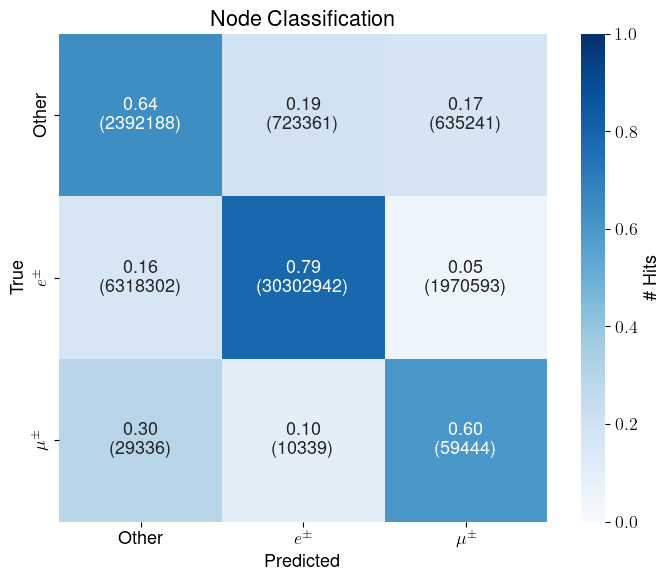

In [37]:
plot_confusion_matrix(
    y_node_true_flat,
    y_node_pred_flat,
    normalize=True,
    class_names=[hit.latex_name for hit in hits],
    cbar_label=r"\# Hits",
    title="Node Classification",
)

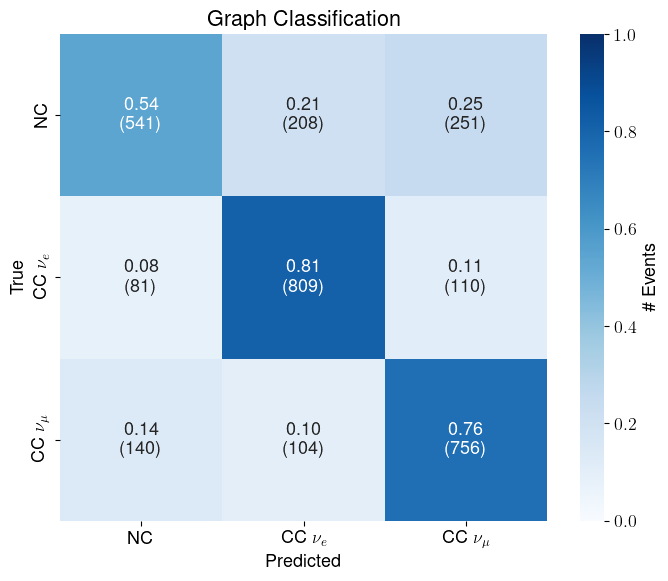

In [29]:
plot_confusion_matrix(
    y_graph_true_flat,
    y_graph_pred_flat,
    normalize=True,
    class_names=[nu.latex_name for nu in nus],
    cbar_label=r"\# Events",
    title="Graph Classification",
)

In [30]:
# plot_precision_recall_curve(
#     y_true=y_node_true_flat,
#     y_prob=y_node_prob_flat,
#     class_names=[nu.latex_name for nu in nus],
# )

In [31]:
# plot_roc_curve(
#     y_true=y_node_true_flat,
#     y_prob=y_node_prob_flat,
#     class_names=[hit.latex_name for hit in hits],
#     figure_path=figures_path / "roc_curve.png",
# )

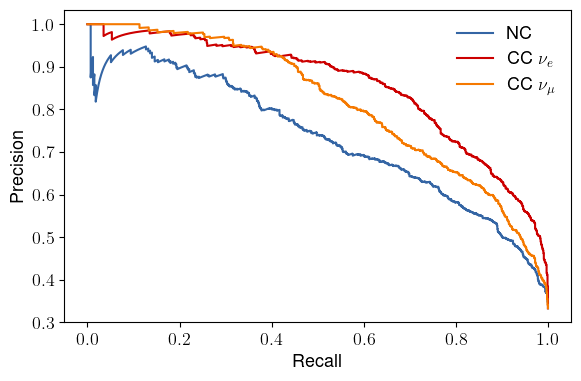

In [38]:
plot_precision_recall_curve(
    y_true=y_graph_true_flat,
    y_prob=y_graph_prob_flat,
    class_names=[nu.latex_name for nu in nus],
)

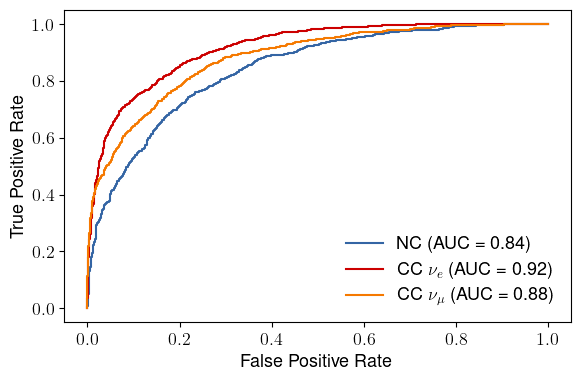

In [39]:
plot_roc_curve(
    y_true=y_graph_true_flat,
    y_prob=y_graph_prob_flat,
    class_names=[nu.latex_name for nu in nus],
    figure_path=figures_path / "roc_curve.png",
)

3750790.0
3750790.0
3750790.0


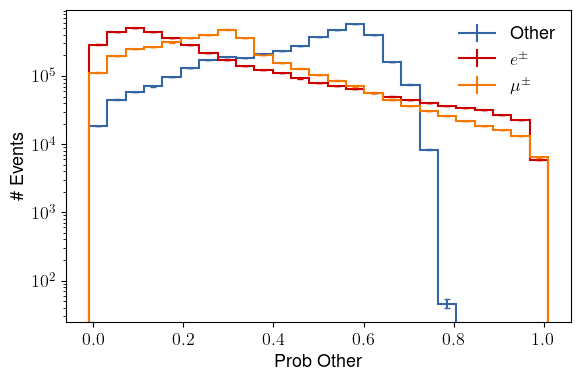

38591837.0
38591837.0
38591837.0


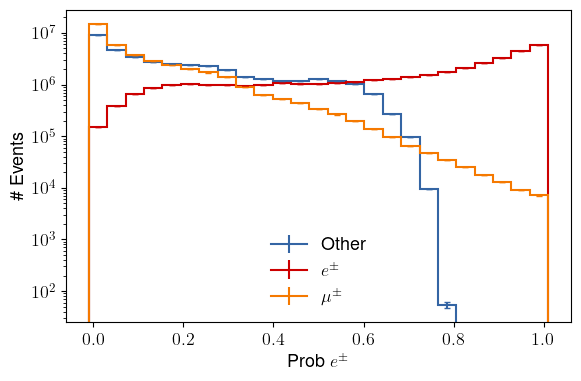

99119.0
99119.0
99119.0


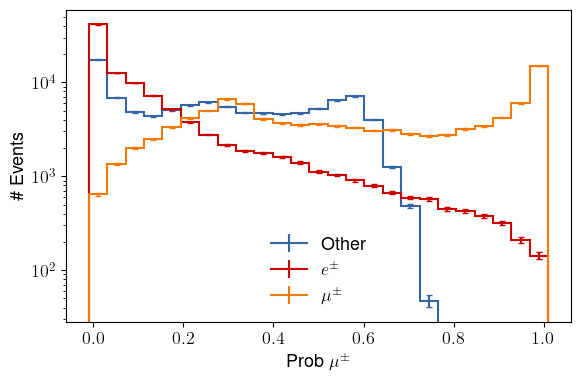

In [40]:
plot_probabilities(
    y_true=y_node_true_flat,
    y_prob=y_node_prob_flat,
    class_names=[hit.latex_name for hit in hits],
    yscale="log",
    num_bins=25,
)

1000.0
1000.0
1000.0


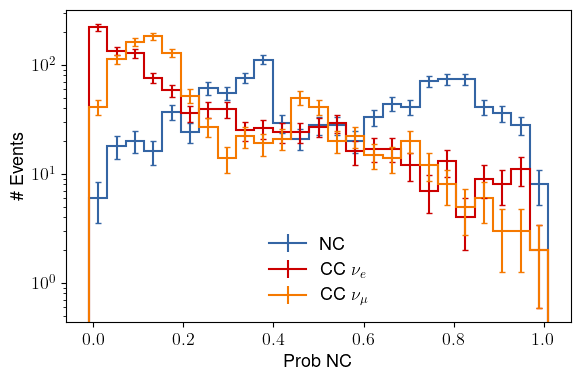

1000.0
1000.0
1000.0


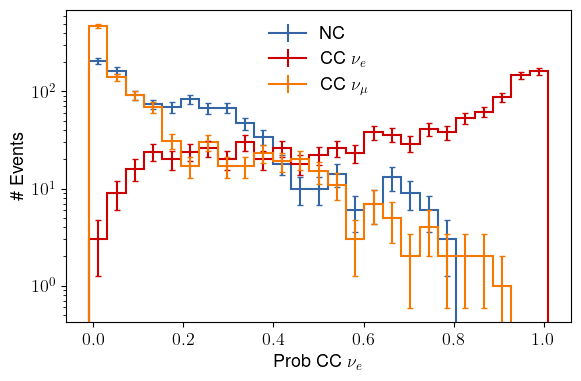

1000.0
1000.0
1000.0


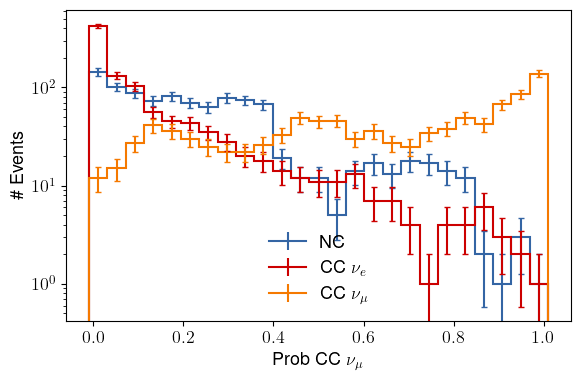

In [41]:
plot_probabilities(
    y_true=y_graph_true_flat,
    y_prob=y_graph_prob_flat,
    class_names=[nu.latex_name for nu in nus],
    yscale="log",
    num_bins=25,
)

In [42]:
def optimize_probability_cut(
    y_true, y_prob, signal_class, threshold_range=np.linspace(0, 1, 101)
):
    """
    Optimize probability cut to maximize figure of merit s/sqrt(s+b).

    Args:
        y_true: True class labels
        y_prob: Predicted probabilities for each class
        signal_class: Index of the signal class
        threshold_range: Array of thresholds to scan

    Returns:
        optimal_threshold: Threshold that maximizes FOM
        optimal_fom: Maximum FOM value
        efficiency: Signal efficiency at optimal threshold
        background_rejection: Background rejection at optimal threshold
        results: Dictionary with all threshold scan results
    """
    # Get probability for signal class
    y_prob_signal = y_prob[:, signal_class]

    # Define signal and background masks
    is_signal = y_true == signal_class
    is_background = ~is_signal

    total_signal = is_signal.sum()
    total_background = is_background.sum()

    # Arrays to store results
    foms = []
    efficiencies = []
    background_rejections = []
    signal_counts = []
    background_counts = []

    for threshold in threshold_range:
        # Events passing the cut
        passes_cut = y_prob_signal >= threshold

        # Count signal and background passing cut
        s = (is_signal & passes_cut).sum()
        b = (is_background & passes_cut).sum()

        # Calculate FOM
        if s + b > 0:
            fom = s / np.sqrt(s + b)
        else:
            fom = 0

        # Calculate efficiency and background rejection
        efficiency = s / total_signal if total_signal > 0 else 0
        background_rejection = 1 - (b / total_background) if total_background > 0 else 1

        foms.append(fom)
        efficiencies.append(efficiency)
        background_rejections.append(background_rejection)
        signal_counts.append(s)
        background_counts.append(b)

    # Find optimal threshold
    foms = np.array(foms)
    efficiencies = np.array(efficiencies)
    background_rejections = np.array(background_rejections)

    optimal_idx = np.argmax(foms)
    optimal_threshold = threshold_range[optimal_idx]
    optimal_fom = foms[optimal_idx]
    optimal_efficiency = efficiencies[optimal_idx]
    optimal_background_rejection = background_rejections[optimal_idx]

    results = {
        "thresholds": threshold_range,
        "foms": foms,
        "efficiencies": efficiencies,
        "background_rejections": background_rejections,
        "signal_counts": np.array(signal_counts),
        "background_counts": np.array(background_counts),
    }

    return (
        optimal_threshold,
        optimal_fom,
        optimal_efficiency,
        optimal_background_rejection,
        results,
    )


# Example: Optimize for CC νμ as signal (class 2)
for signal_class in range(3):
    print("-" * 40)
    print("class:", signal_class)
    opt_threshold, opt_fom, opt_eff, opt_bg_rej, results = optimize_probability_cut(
        y_graph_true_flat, y_graph_prob_flat, signal_class=signal_class
    )

    print(f"Signal class: {nus[signal_class].latex_name}")
    print(f"Optimal threshold: {opt_threshold:.3f}")
    print(f"Maximum FOM (s/√(s+b)): {opt_fom:.2f}")
    print(f"Signal efficiency: {opt_eff:.3f} ({opt_eff * 100:.1f}%)")
    print(f"Background rejection: {opt_bg_rej:.3f} ({opt_bg_rej * 100:.1f}%)")
    print(f"\nAt optimal cut:")
    print(
        f"  Signal events: {results['signal_counts'][np.argmax(results['foms'])]:.0f}"
    )
    print(
        f"  Background events: {results['background_counts'][np.argmax(results['foms'])]:.0f}"
    )
    print("-" * 40)

----------------------------------------
class: 0
Signal class: NC
Optimal threshold: 0.240
Maximum FOM (s/√(s+b)): 21.73
Signal efficiency: 0.871 (87.1%)
Background rejection: 0.633 (63.3%)

At optimal cut:
  Signal events: 871
  Background events: 735
----------------------------------------
----------------------------------------
class: 1
Signal class: CC $\nu_{e}$
Optimal threshold: 0.320
Maximum FOM (s/√(s+b)): 24.12
Signal efficiency: 0.856 (85.6%)
Background rejection: 0.798 (79.8%)

At optimal cut:
  Signal events: 856
  Background events: 404
----------------------------------------
----------------------------------------
class: 2
Signal class: CC $\nu_{\mu}$
Optimal threshold: 0.220
Maximum FOM (s/√(s+b)): 23.02
Signal efficiency: 0.854 (85.4%)
Background rejection: 0.739 (73.9%)

At optimal cut:
  Signal events: 854
  Background events: 522
----------------------------------------
